# Strategy Testing
In this notebook various tests are ran on mockups to explain the process behind implementing the strategy. Such functions implemented to aid the strategy are the rolling z-score and signal generator in [`strategy.py`](../src/strategy.py).

## Rolling Z-score
In this function we aim to compute the z-score using a rolling mean and rolling standard deviation. This allows us to account for only knowing information at the previous states and not using look-ahead bias. In order to test this we create a mean-reverting series to act as our test spread, and run the rolling_zscore function on this. We expect that the mean should be close to zero since all the z-scores describe the mean-reversion of the series. Furthermore, we expect a standard deviation of around one and a min or max of around ±2-3.

In [22]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import numpy as np
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))
from strategy import rolling_zscore, generate_signals_stateless, generate_signals_stateful
from backtester import extract_trades
from cointegration import engle_granger_test
from data_loader import download_prices

np.random.seed(42)
n = 1000
phi = 0.9
ar = np.zeros(n)
shocks = np.random.normal(0, 1, n)
for i in range(1, n):
    ar[i] = phi * ar[i-1] + shocks[i]
spread = pd.Series(ar)

z = rolling_zscore(spread, window=60)

print(z.describe())



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
count    941.000000
mean       0.067436
std        1.126697
min       -2.901968
25%       -0.721996
50%        0.002709
75%        0.834848
max        2.963693
dtype: float64


Next, we plot the z-score and spread to confirm that the z-score seems to cross ±2 when the spread stretches, and zero when the spread reverts.

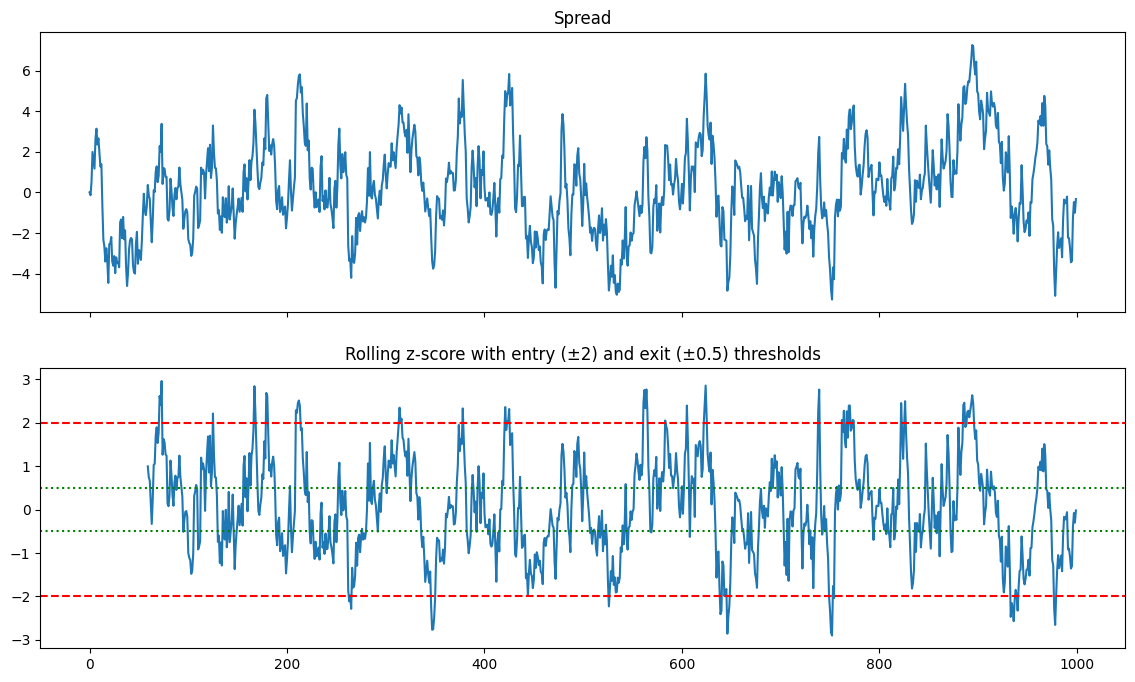

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(spread); ax1.set_title('Spread')
ax2.plot(z); ax2.axhline(2, color='r', ls='--'); ax2.axhline(-2, color='r', ls='--')
ax2.axhline(0.5, color='g', ls=':'); ax2.axhline(-0.5, color='g', ls=':')
ax2.set_title('Rolling z-score with entry (±2) and exit (±0.5) thresholds')
plt.show()

Using the rolling_zscore function along with our stateless signal generator, we can also check the proportions of short entries, long entries, and flat segments. This allows for a basic sanity check where we can eyeball the generator at work. We note that since this generator is stateless, the regions between entry and exit thresholds are considered ambigous. This is because the generator does not hold information regarding if we are holding a short or long position.

In [24]:
# Load EWA/EWC, get the spread from the hedge ratio
prices = download_prices(['EWA', 'EWC'], '2015-01-01', '2024-12-31')
eg = engle_granger_test(prices['EWA'], prices['EWC'])
spread = eg['residuals']

z = rolling_zscore(spread, window=60)
signals_stateless = generate_signals_stateless(z)

# How many entry signals?
print(f"Long-spread entries: {(signals_stateless == 1).sum()}")
print(f"Short-spread entries: {(signals_stateless == -1).sum()}")
print(f"Flat: {(signals_stateless == 0).sum()}")

Long-spread entries: 141
Short-spread entries: 148
Flat: 2226


We can also compare these results to the implemented stateful signal generator. We expect that there should be less flat days since it will be holding at some of those positions. This also means we expect more long-spread and short-spread days.

In [25]:
signals_stateful = generate_signals_stateful(z)

# How many entry signals?
print(f"Long-spread entries: {(signals_stateful == 1).sum()}")
print(f"Short-spread entries: {(signals_stateful == -1).sum()}")
print(f"Flat: {(signals_stateful == 0).sum()}")

Long-spread entries: 458
Short-spread entries: 508
Flat: 1549


Moreover, we can plot the stateful and stateless signals on top of the z-scores. This will allow a visual confirmation that we are entering and exiting position at the proper z-score thresholds.

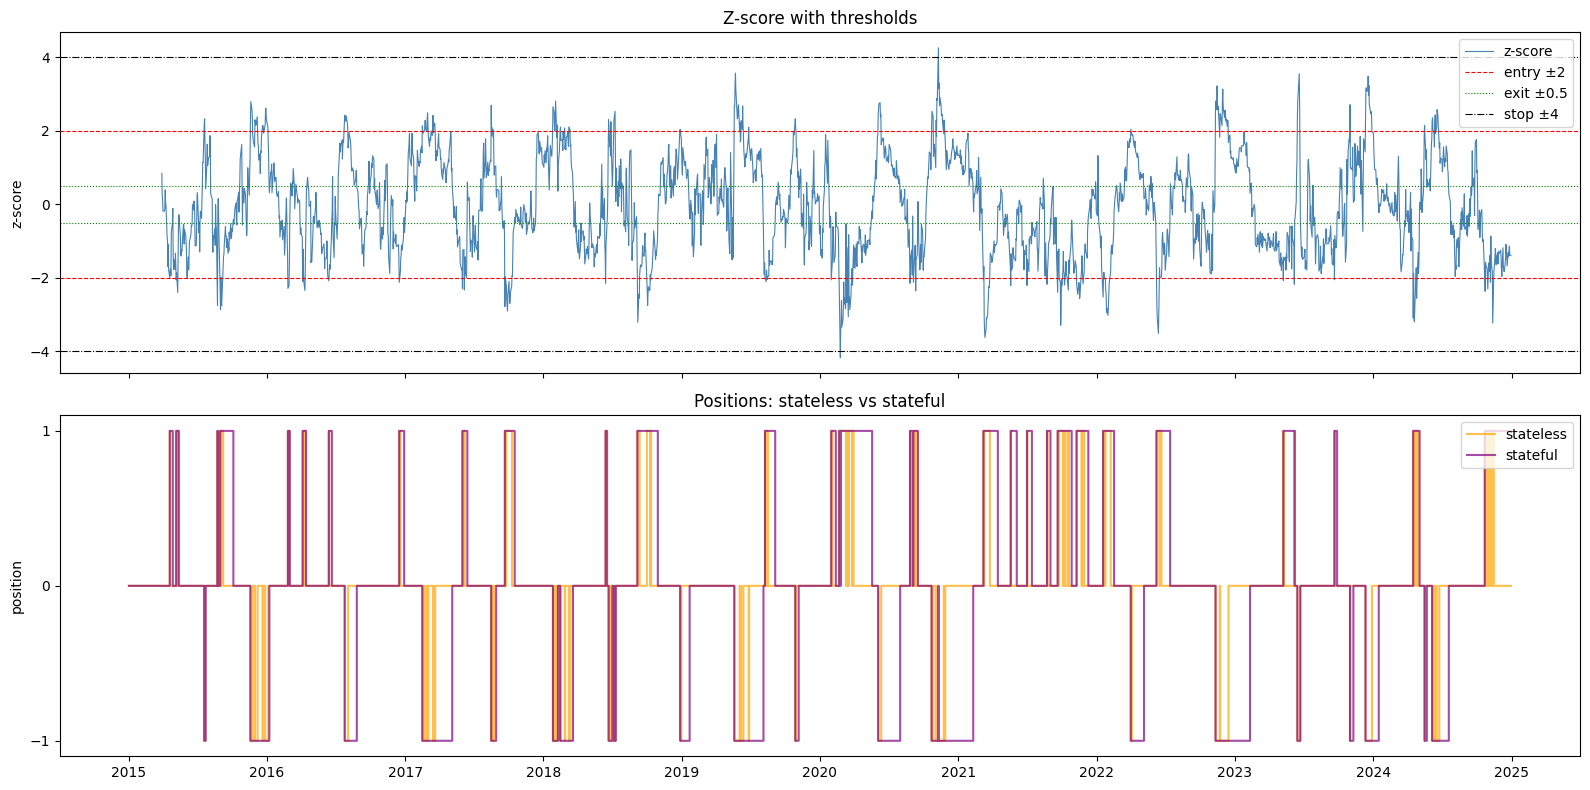

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top panel: z-score with threshold lines
ax1.plot(z, color='steelblue', lw=0.8, label='z-score')
ax1.axhline(2, color='red', ls='--', lw=0.8, label='entry ±2')
ax1.axhline(-2, color='red', ls='--', lw=0.8)
ax1.axhline(0.5, color='green', ls=':', lw=0.8, label='exit ±0.5')
ax1.axhline(-0.5, color='green', ls=':', lw=0.8)
ax1.axhline(4, color='black', ls='-.', lw=0.8, label='stop ±4')
ax1.axhline(-4, color='black', ls='-.', lw=0.8)
ax1.set_ylabel('z-score')
ax1.legend(loc='upper right')
ax1.set_title('Z-score with thresholds')

# Bottom panel: both position series
ax2.step(signals_stateless.index, signals_stateless, where='post',
         color='orange', alpha=0.7, label='stateless')
ax2.step(signals_stateful.index, signals_stateful, where='post',
         color='purple', alpha=0.7, label='stateful')
ax2.set_ylabel('position')
ax2.set_yticks([-1, 0, 1])
ax2.legend(loc='upper right')
ax2.set_title('Positions: stateless vs stateful')

plt.tight_layout()
plt.show()

In [27]:
z = rolling_zscore(spread, window=60)
sig = generate_signals_stateful(z)

# Find where z crossed the stop
stop_dates = z[(z < -4) | (z > 4)].index
print("Dates where |z| > 4:")
for d in stop_dates:
    print(f"{d.date()}  z={z[d]:.2f}  position={sig[d]}")

Dates where |z| > 4:
2020-02-24  z=-4.18  position=0
2020-11-09  z=4.25  position=0


We can also find the exact dates where the stop loss was triggered. In Febuary 2020 COVID-19 caused a widespread global supply chain disruption - greatly damaging the trust in markets. On the other hand, November 2020 was when the news of a vaccine was announced, leading many to believe recovery was imminent in the global economy.

## Extracting Trades
In this part we run a function designed to follow the positions array generated from the stateful signal generator. This function, `extract_trades` returns a DataFrame containing the entry and exit dates, position type (short, long),  holding period, and if the trade has not been closed it flags is using the still_open column.

In [28]:
z = rolling_zscore(spread, window=60)
positions = generate_signals_stateful(z)
trades = extract_trades(positions)

completed = trades[trades['still_open']==False]
print(f"Completed trades: {len(completed)}")
print(f"Avg holding period: {completed['holding_period'].mean():.1f} bars")
print(f"Long / short: {(completed['direction']==1).sum()} / {(completed['direction']==-1).sum()}")

Completed trades: 51
Avg holding period: 18.0 bars
Long / short: 29 / 22


Importantly, the average holding period of 18 days lines up exactly with our predicted half life of 14.6 days for the EWA/EWC pair in sample.